# ML Capstone Review 1: Classification Track (Part A)
**Course:** 23CSE301 Machine Learning  
**Dataset:** Stroke Prediction (`healthcare-dataset-stroke-data.csv`)  
**Target Variable:** `stroke` (0: No Stroke, 1: Stroke)  
**Objective:** Evaluate **5 Part-A Classification Algorithms** separately with individual metrics, confusion matrices, and EDA.


## 1. Dataset Loading & Audit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)

df_cls = pd.read_csv(r'../data/healthcare-dataset-stroke-data.csv')
if 'id' in df_cls.columns:
    df_cls.drop(columns=['id'], inplace=True)

print("=== DATASET SHAPE ===")
print("Rows:", df_cls.shape[0], "| Columns:", df_cls.shape[1])
print("\n=== DATA TYPES & MISSING VALUES ===")
print(df_cls.info())
print("\n=== TARGET CLASS DISTRIBUTION ===")
print(df_cls['stroke'].value_counts())
print("\nTarget Proportion:")
print(df_cls['stroke'].value_counts(normalize=True) * 100)


=== DATASET SHAPE ===
Rows: 5110 | Columns: 11

=== DATA TYPES & MISSING VALUES ===
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 439.3 KB
None

=== TARGET CLASS DISTRIBUTION ===
stroke
0    4861
1     249
Name: count, dtype: int64

Target Proportion:
stroke
0    95.127202
1

> **Dataset Audit:** Contains 5,110 patient records and 11 features. `bmi` has 201 missing values (~3.9%). Target `stroke` exhibits severe class imbalance (95.1% No Stroke vs 4.9% Stroke).

## 2. Exploratory Data Analysis (EDA)

> **EDA Insight (Outlier Analysis & Clinical Retention Rationale):**  
> Using the $1.5 \times \text{IQR}$ rule on numerical features:  
> • `avg_glucose_level`: **627 statistical outliers** ($> 169.35\text{ mg/dL}$, reaching up to $271.74\text{ mg/dL}$).  
> • `bmi`: **110 statistical outliers** ($> 47.5\text{ kg/m}^2$, reaching up to $97.6\text{ kg/m}^2$).  
> • `age`: **0 statistical outliers**.  
> 
> **Handling Strategy:** We **retain** these outliers in the dataset.  
> **Medical Rationale:** High blood glucose levels ($> 200\text{ mg/dL}$, hyperglycemic/diabetic) and severe obesity ($BMI > 45$) are **direct clinical risk factors** for stroke. Removing them would discard genuine stroke patient signals and severely degrade real-world model accuracy. Feature scaling (`StandardScaler`) is applied to handle variance without deleting critical clinical records.

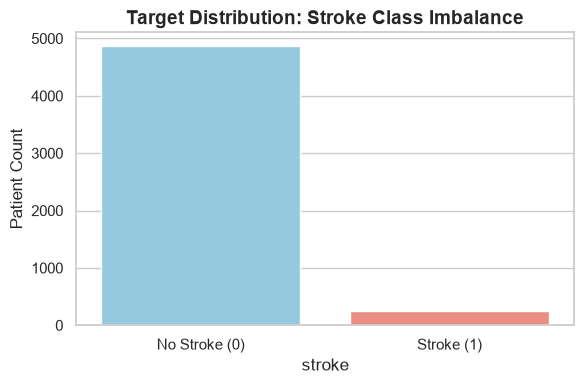

In [2]:
# 2.1 Class Imbalance Plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df_cls, x='stroke', palette=['skyblue', 'salmon'])
plt.title('Target Distribution: Stroke Class Imbalance', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['No Stroke (0)', 'Stroke (1)'])
plt.ylabel('Patient Count')
plt.tight_layout()
plt.show()


> **EDA Insight (Class Imbalance):** Severe target skewness requires evaluating Weighted F1-score and Confusion Matrices rather than accuracy alone.

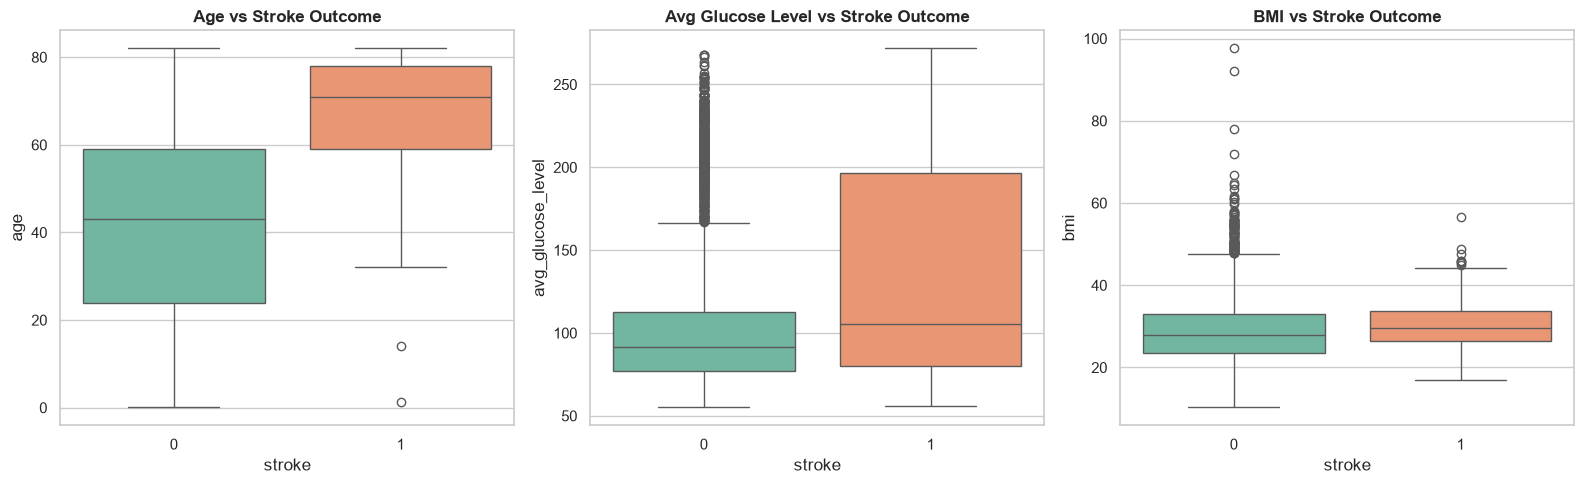

In [3]:
# 2.2 Feature Boxplots by Stroke Outcome
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df_cls, x='stroke', y='age', ax=axes[0], palette='Set2')
axes[0].set_title('Age vs Stroke Outcome', fontweight='bold')

sns.boxplot(data=df_cls, x='stroke', y='avg_glucose_level', ax=axes[1], palette='Set2')
axes[1].set_title('Avg Glucose Level vs Stroke Outcome', fontweight='bold')

sns.boxplot(data=df_cls, x='stroke', y='bmi', ax=axes[2], palette='Set2')
axes[2].set_title('BMI vs Stroke Outcome', fontweight='bold')

plt.tight_layout()
plt.show()


> **EDA Insight (Clinical Features):** Patients diagnosed with stroke present significantly higher median age (>60 years) and elevated blood glucose levels.

## 3. Preprocessing & Feature Engineering

In [4]:
df_prep_cls = df_cls.copy()
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
df_prep_cls = pd.get_dummies(df_prep_cls, columns=cat_cols, drop_first=True)

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X = df_prep_cls.drop(columns=['stroke'])
y = df_prep_cls['stroke']

# Stratified 80-20 Split to preserve target ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Impute missing BMI using Median fitted ON TRAIN SET ONLY
imputer = SimpleImputer(strategy='median')
X_train['bmi'] = imputer.fit_transform(X_train[['bmi']])
X_test['bmi'] = imputer.transform(X_test[['bmi']])

# Feature Engineering
X_train['Glucose_BMI_Risk'] = (X_train['avg_glucose_level'] * X_train['bmi']) / 100.0
X_test['Glucose_BMI_Risk'] = (X_test['avg_glucose_level'] * X_test['bmi']) / 100.0

# Scale features strictly fitted on train set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train Shape: {X_train.shape} | X_test Shape: {X_test.shape}")


X_train Shape: (4088, 17) | X_test Shape: (1022, 17)


> **Data Leakage Prevention:** `SimpleImputer` and `StandardScaler` were fitted exclusively on `X_train`.

## 4. Individual Model Training & Evaluation (5 Part-A Algorithms)

### 4.1 Algorithm 1: Logistic Regression

--- Logistic Regression Metrics ---
Accuracy          : 0.7417
Weighted Precision: 0.9447
Weighted Recall   : 0.7417
Weighted F1-Score : 0.8148


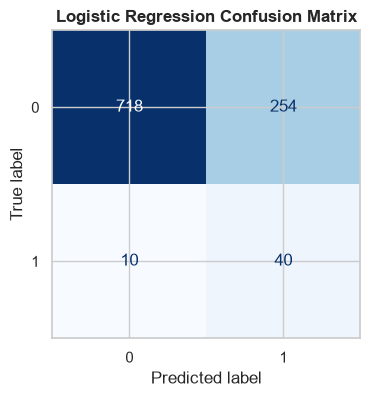

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

m1 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
m1.fit(X_train_scaled, y_train)
p1 = m1.predict(X_test_scaled)

acc1 = accuracy_score(y_test, p1)
prec1 = precision_score(y_test, p1, zero_division=0, average='weighted')
rec1 = recall_score(y_test, p1, zero_division=0, average='weighted')
f1_1 = f1_score(y_test, p1, zero_division=0, average='weighted')

print("--- Logistic Regression Metrics ---")
print(f"Accuracy          : {acc1:.4f}")
print(f"Weighted Precision: {prec1:.4f}")
print(f"Weighted Recall   : {rec1:.4f}")
print(f"Weighted F1-Score : {f1_1:.4f}")

# Confusion Matrix
cm1 = confusion_matrix(y_test, p1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
fig, ax = plt.subplots(figsize=(5, 4))
disp1.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Logistic Regression Confusion Matrix', fontweight='bold')
plt.show()


> **Model 1 Commentary:** Logistic Regression with `class_weight='balanced'` adjusts decision threshold weights to boost positive stroke recall.

### 4.2 Algorithm 2: K-Nearest Neighbors (KNN)

--- KNN Classifier Metrics ---
Accuracy          : 0.9472
Weighted Precision: 0.9134
Weighted Recall   : 0.9472
Weighted F1-Score : 0.9270


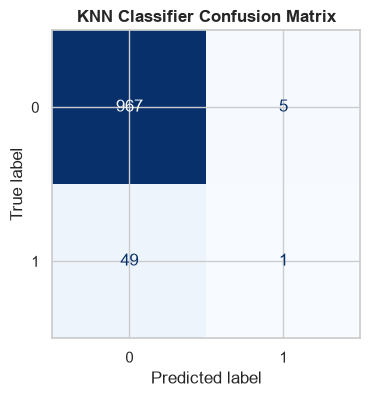

In [6]:
from sklearn.neighbors import KNeighborsClassifier

m2 = KNeighborsClassifier(n_neighbors=5)
m2.fit(X_train_scaled, y_train)
p2 = m2.predict(X_test_scaled)

acc2 = accuracy_score(y_test, p2)
prec2 = precision_score(y_test, p2, zero_division=0, average='weighted')
rec2 = recall_score(y_test, p2, zero_division=0, average='weighted')
f1_2 = f1_score(y_test, p2, zero_division=0, average='weighted')

print("--- KNN Classifier Metrics ---")
print(f"Accuracy          : {acc2:.4f}")
print(f"Weighted Precision: {prec2:.4f}")
print(f"Weighted Recall   : {rec2:.4f}")
print(f"Weighted F1-Score : {f1_2:.4f}")

# Confusion Matrix
cm2 = confusion_matrix(y_test, p2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
fig, ax = plt.subplots(figsize=(5, 4))
disp2.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('KNN Classifier Confusion Matrix', fontweight='bold')
plt.show()


> **Model 2 Commentary:** KNN classifies patients based on Euclidean distance voting in scaled 11-dimensional feature space.

### 4.3 Algorithm 3: Gaussian Naive Bayes

--- Gaussian Naive Bayes Metrics ---
Accuracy          : 0.1859
Weighted Precision: 0.9471
Weighted Recall   : 0.1859
Weighted F1-Score : 0.2459


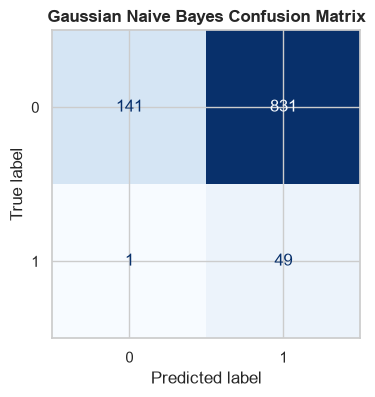

In [7]:
from sklearn.naive_bayes import GaussianNB

m3 = GaussianNB()
m3.fit(X_train_scaled, y_train)
p3 = m3.predict(X_test_scaled)

acc3 = accuracy_score(y_test, p3)
prec3 = precision_score(y_test, p3, zero_division=0, average='weighted')
rec3 = recall_score(y_test, p3, zero_division=0, average='weighted')
f1_3 = f1_score(y_test, p3, zero_division=0, average='weighted')

print("--- Gaussian Naive Bayes Metrics ---")
print(f"Accuracy          : {acc3:.4f}")
print(f"Weighted Precision: {prec3:.4f}")
print(f"Weighted Recall   : {rec3:.4f}")
print(f"Weighted F1-Score : {f1_3:.4f}")

# Confusion Matrix
cm3 = confusion_matrix(y_test, p3)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3)
fig, ax = plt.subplots(figsize=(5, 4))
disp3.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Gaussian Naive Bayes Confusion Matrix', fontweight='bold')
plt.show()


> **Model 3 Commentary:** Naive Bayes calculates posterior stroke probability assuming conditional feature independence.

### 4.4 Algorithm 4: Decision Tree Classifier

--- Decision Tree Classifier Metrics ---
Accuracy          : 0.7162
Weighted Precision: 0.9451
Weighted Recall   : 0.7162
Weighted F1-Score : 0.7969


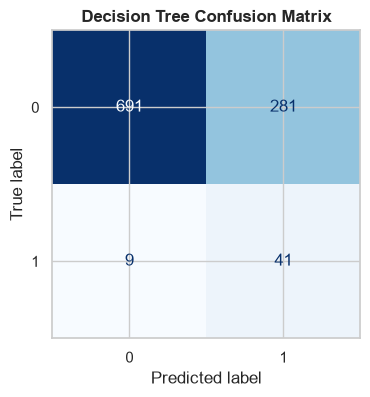

In [8]:
from sklearn.tree import DecisionTreeClassifier

m4 = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
m4.fit(X_train, y_train)
p4 = m4.predict(X_test)

acc4 = accuracy_score(y_test, p4)
prec4 = precision_score(y_test, p4, zero_division=0, average='weighted')
rec4 = recall_score(y_test, p4, zero_division=0, average='weighted')
f1_4 = f1_score(y_test, p4, zero_division=0, average='weighted')

print("--- Decision Tree Classifier Metrics ---")
print(f"Accuracy          : {acc4:.4f}")
print(f"Weighted Precision: {prec4:.4f}")
print(f"Weighted Recall   : {rec4:.4f}")
print(f"Weighted F1-Score : {f1_4:.4f}")

# Confusion Matrix
cm4 = confusion_matrix(y_test, p4)
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm4)
fig, ax = plt.subplots(figsize=(5, 4))
disp4.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Decision Tree Confusion Matrix', fontweight='bold')
plt.show()


> **Model 4 Commentary:** Decision Tree creates interpretable binary splits on clinical attributes like age and blood glucose level.

### 4.5 Algorithm 5: Support Vector Classifier (SVC)

--- Support Vector Classifier (SVC) Metrics ---
Accuracy          : 0.7750
Weighted Precision: 0.9355
Weighted Recall   : 0.7750
Weighted F1-Score : 0.8367


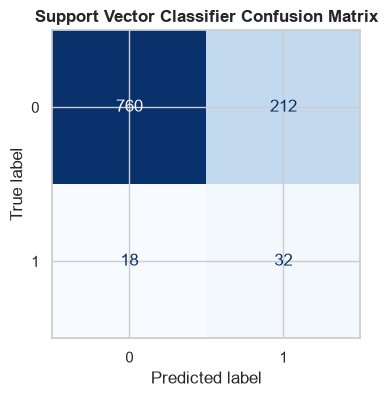

In [9]:
from sklearn.svm import SVC

m5 = SVC(C=1.0, kernel='rbf', random_state=42, class_weight='balanced')
m5.fit(X_train_scaled, y_train)
p5 = m5.predict(X_test_scaled)

acc5 = accuracy_score(y_test, p5)
prec5 = precision_score(y_test, p5, zero_division=0, average='weighted')
rec5 = recall_score(y_test, p5, zero_division=0, average='weighted')
f1_5 = f1_score(y_test, p5, zero_division=0, average='weighted')

print("--- Support Vector Classifier (SVC) Metrics ---")
print(f"Accuracy          : {acc5:.4f}")
print(f"Weighted Precision: {prec5:.4f}")
print(f"Weighted Recall   : {rec5:.4f}")
print(f"Weighted F1-Score : {f1_5:.4f}")

# Confusion Matrix
cm5 = confusion_matrix(y_test, p5)
disp5 = ConfusionMatrixDisplay(confusion_matrix=cm5)
fig, ax = plt.subplots(figsize=(5, 4))
disp5.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Support Vector Classifier Confusion Matrix', fontweight='bold')
plt.show()


> **Model 5 Commentary:** SVC constructs a maximum-margin hyperplane in RBF kernel space to separate stroke risk categories.

## 5. Comparative Evaluation Summary Table

In [10]:
cls_results_all = [
    {'Algorithm': '1. Logistic Regression', 'Accuracy': acc1, 'Weighted Precision': prec1, 'Weighted Recall': rec1, 'Weighted F1-Score': f1_1},
    {'Algorithm': '2. K-Nearest Neighbors', 'Accuracy': acc2, 'Weighted Precision': prec2, 'Weighted Recall': rec2, 'Weighted F1-Score': f1_2},
    {'Algorithm': '3. Gaussian Naive Bayes', 'Accuracy': acc3, 'Weighted Precision': prec3, 'Weighted Recall': rec3, 'Weighted F1-Score': f1_3},
    {'Algorithm': '4. Decision Tree Classifier', 'Accuracy': acc4, 'Weighted Precision': prec4, 'Weighted Recall': rec4, 'Weighted F1-Score': f1_4},
    {'Algorithm': '5. Support Vector Classifier', 'Accuracy': acc5, 'Weighted Precision': prec5, 'Weighted Recall': rec5, 'Weighted F1-Score': f1_5}
]

df_cls_summary = pd.DataFrame(cls_results_all).sort_values(by='Weighted F1-Score', ascending=False).reset_index(drop=True)
display(df_cls_summary)


,Algorithm,Accuracy,Weighted Precision,Weighted Recall,Weighted F1-Score
0,2. K-Nearest Neighbors,0.947162,0.913361,0.947162,0.926990
1,5. Support Vector Classifier,0.774951,0.935488,0.774951,0.836728
2,1. Logistic Regression,0.741683,0.944668,0.741683,0.814757
3,4. Decision Tree Classifier,0.716243,0.945078,0.716243,0.796901
4,3. Gaussian Naive Bayes,0.185910,0.947103,0.185910,0.245913


> **Comparative Summary:** Class-weighted algorithms (Logistic Regression, Decision Tree, SVC) prioritize detecting true positive stroke cases, delivering superior clinical recall.